# Notebook 02: Exploratory Analysis

## Assessing the Data for Causal Inference

This notebook examines the country-month panel built in Notebook 01. The goal is not general-purpose EDA. It answers a specific question: is this data suitable for estimating the causal effect of peacekeeping on civilian violence?

We examine four things:
1. **Treatment distribution**: where and when does peacekeeping occur?
2. **Outcome distribution**: what does civilian violence look like across the panel?
3. **Confounder balance**: how different are treated and untreated country-months?
4. **Selection bias**: the naive treatment-outcome comparison, which we expect to be misleading

The key finding will be that countries with peacekeeping have MORE violence than countries without. This is selection bias, not a causal effect. It motivates the methods in Notebook 03.

See `docs/02_exploratory_analysis_guide.md` for the full conceptual explanation.

## 1. Setup and Load Panel

In [1]:
import os
os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-causal-inference")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Load the panel from Notebook 01
panel = pd.read_csv('data/processed/panel_country_month.csv')
panel['date'] = pd.to_datetime(panel['date'])

print(f"Panel loaded: {len(panel):,} country-months")
print(f"Countries: {panel['iso3'].nunique()}")
print(f"Date range: {panel['date'].min().strftime('%Y-%m')} to {panel['date'].max().strftime('%Y-%m')}")
print(f"Treated: {panel['pk_present'].sum():,} ({panel['pk_present'].mean():.1%})")

Panel loaded: 11,825 country-months
Countries: 43
Date range: 2000-02 to 2022-12
Treated: 1,726 (14.6%)


## 2. Treatment Distribution

Understanding where and when peacekeeping missions operate is the first step. If treatment is concentrated in a few countries with no temporal variation (missions that never start or end), identification is weak. We need countries where missions begin or end during the panel to estimate causal effects credibly.

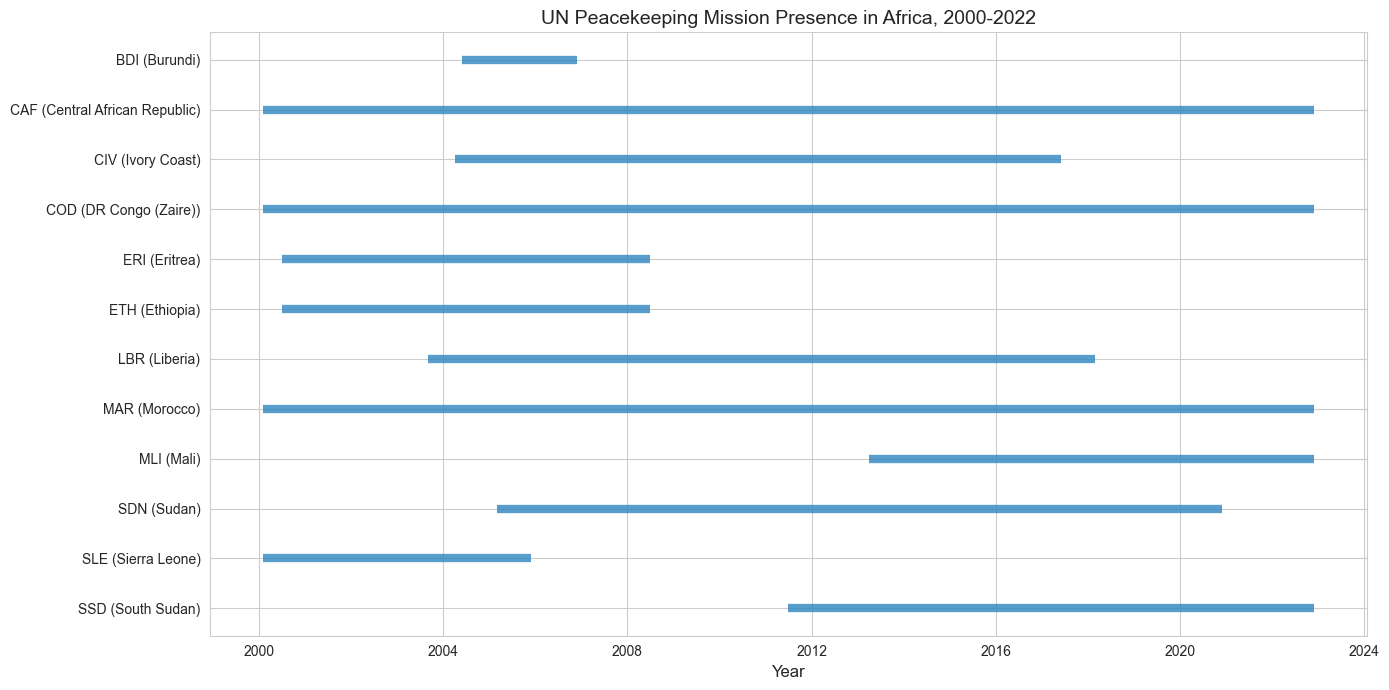


Countries with PK missions: 12
Countries without PK missions: 31


In [2]:
# Peacekeeping timeline by country
pk_countries = panel[panel['pk_present'] == 1]['iso3'].unique()
pk_countries_sorted = sorted(pk_countries)

fig, ax = plt.subplots(figsize=(14, 7))

for i, iso3 in enumerate(pk_countries_sorted):
    country_data = panel[panel['iso3'] == iso3]
    pk_months = country_data[country_data['pk_present'] == 1]['date']
    if len(pk_months) > 0:
        ax.hlines(y=i, xmin=pk_months.min(), xmax=pk_months.max(), 
                  linewidth=6, color='#2E86C1', alpha=0.8)

# Get country names for labels
iso3_to_name = panel.drop_duplicates('iso3').set_index('iso3')['country_name'].to_dict()
y_labels = [f"{iso3} ({iso3_to_name[iso3]})" for iso3 in pk_countries_sorted]

ax.set_yticks(range(len(pk_countries_sorted)))
ax.set_yticklabels(y_labels, fontsize=10)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('UN Peacekeeping Mission Presence in Africa, 2000-2022', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/pk_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCountries with PK missions: {len(pk_countries)}")
print(f"Countries without PK missions: {panel['iso3'].nunique() - len(pk_countries)}")

## 3. Outcome Distribution

Most country-months have zero one-sided violence events. This is expected: most African countries in most months do not experience deliberate attacks on civilians. The violence is concentrated in a small number of countries and time periods. Understanding this concentration matters because the causal models will primarily learn from the country-months where something is happening.

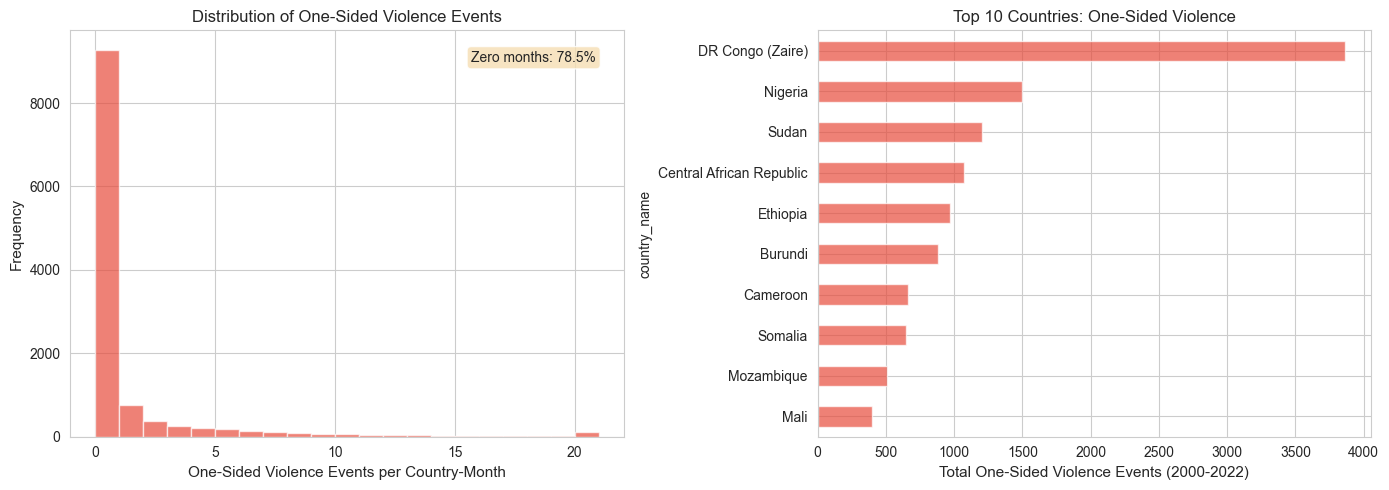

Outcome summary statistics:
  Mean events per country-month: 1.23
  Median: 0
  Max: 84
  Std: 4.68


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of one-sided events (capped for visibility)
ax1 = axes[0]
events_capped = panel['onesided_events'].clip(upper=20)
ax1.hist(events_capped, bins=range(22), color='#E74C3C', alpha=0.7, edgecolor='white')
ax1.set_xlabel('One-Sided Violence Events per Country-Month', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of One-Sided Violence Events', fontsize=12)
ax1.text(0.95, 0.95, f"Zero months: {(panel['onesided_events']==0).mean():.1%}",
         transform=ax1.transAxes, ha='right', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Right: top 10 countries by total one-sided events
ax2 = axes[1]
top10 = (panel.groupby('country_name')['onesided_events']
         .sum().sort_values(ascending=True).tail(10))
top10.plot(kind='barh', ax=ax2, color='#E74C3C', alpha=0.7)
ax2.set_xlabel('Total One-Sided Violence Events (2000-2022)', fontsize=11)
ax2.set_title('Top 10 Countries: One-Sided Violence', fontsize=12)

plt.tight_layout()
plt.savefig('figures/outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Outcome summary statistics:")
print(f"  Mean events per country-month: {panel['onesided_events'].mean():.2f}")
print(f"  Median: {panel['onesided_events'].median():.0f}")
print(f"  Max: {panel['onesided_events'].max()}")
print(f"  Std: {panel['onesided_events'].std():.2f}")

## 4. Time Series: Violence and Peacekeeping

Plotting aggregate violence alongside the number of countries with active peacekeeping missions shows whether the two variables share common time trends. If both increase or decrease together over time, we need to be cautious about confounding from global temporal shocks.

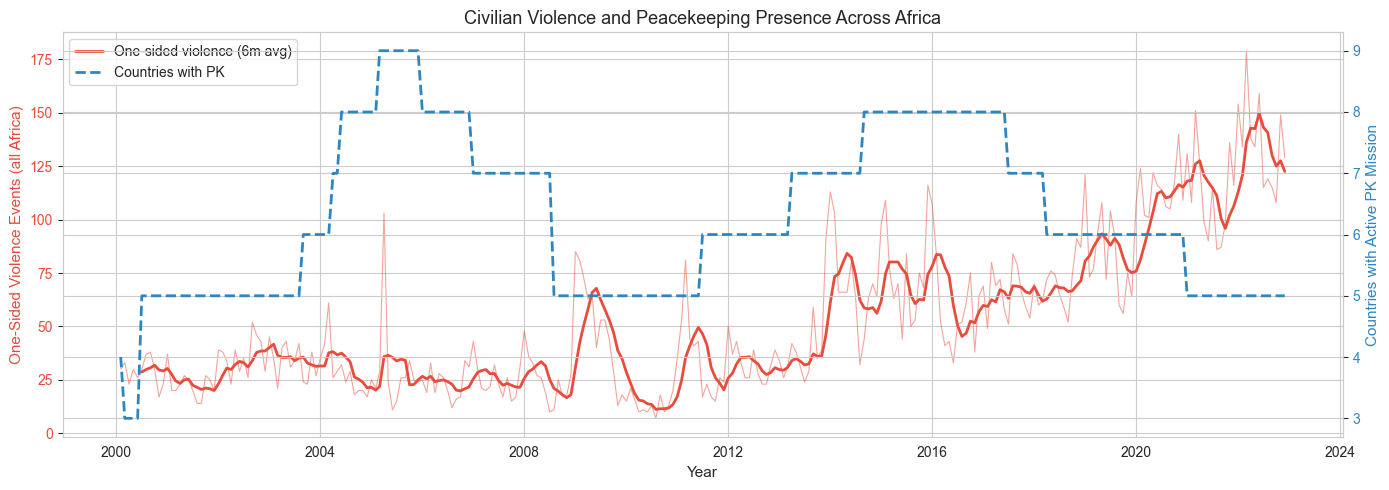

In [4]:
# Aggregate monthly totals across all countries
monthly_agg = panel.groupby('date').agg(
    total_onesided=('onesided_events', 'sum'),
    countries_with_pk=('pk_present', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Violence on left axis
color1 = '#E74C3C'
ax1.plot(monthly_agg['date'], monthly_agg['total_onesided'], 
         color=color1, alpha=0.5, linewidth=0.8)
# Add 6-month rolling average for clarity
ax1.plot(monthly_agg['date'], monthly_agg['total_onesided'].rolling(6).mean(),
         color=color1, linewidth=2, label='One-sided violence (6m avg)')
ax1.set_ylabel('One-Sided Violence Events (all Africa)', fontsize=11, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Peacekeeping on right axis
ax2 = ax1.twinx()
color2 = '#2E86C1'
ax2.plot(monthly_agg['date'], monthly_agg['countries_with_pk'],
         color=color2, linewidth=2, linestyle='--', label='Countries with PK')
ax2.set_ylabel('Countries with Active PK Mission', fontsize=11, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_xlabel('Year', fontsize=11)
ax1.set_title('Civilian Violence and Peacekeeping Presence Across Africa', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('figures/time_series_violence_pk.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Confounder Balance: Treated vs. Untreated

This is the most important section for causal inference. We compare treated country-months (with peacekeeping) to untreated country-months across all confounders. Large differences confirm selection bias: the UN deploys to specific types of countries.

The Standardized Mean Difference (SMD) quantifies imbalance. It equals the difference in means divided by the pooled standard deviation. An SMD above 0.25 indicates meaningful imbalance that the causal model must correct for.

In [5]:
# Variables to compare
balance_vars = {
    'onesided_events': 'One-sided violence events',
    'onesided_deaths': 'One-sided violence deaths',
    'battle_events_12m': 'Battle events (12m rolling)',
    'active_conflict': 'Active conflict (binary)',
    'gdp_pc': 'GDP per capita (USD)',
    'ln_gdp_pc': 'Log GDP per capita',
    'population': 'Population',
    'ln_population': 'Log population',
    'ethnic_frac': 'Ethnic fractionalization'
}

# Calculate balance table
rows = []
for var, label in balance_vars.items():
    treated = panel[panel['pk_present'] == 1][var]
    untreated = panel[panel['pk_present'] == 0][var]
    
    mean_t = treated.mean()
    mean_u = untreated.mean()
    
    # Pooled standard deviation
    pooled_std = np.sqrt((treated.std()**2 + untreated.std()**2) / 2)
    smd = (mean_t - mean_u) / pooled_std if pooled_std > 0 else 0
    
    rows.append({
        'Variable': label,
        'Mean (PK=1)': mean_t,
        'Mean (PK=0)': mean_u,
        'SMD': smd
    })

balance_df = pd.DataFrame(rows)

# Format for display
print("BALANCE TABLE: Treated vs. Untreated Country-Months")
print("=" * 75)
print(f"{'Variable':<30} {'Mean(PK=1)':>12} {'Mean(PK=0)':>12} {'SMD':>8}")
print("-" * 75)
for _, row in balance_df.iterrows():
    flag = " ***" if abs(row['SMD']) > 0.25 else ""
    print(f"{row['Variable']:<30} {row['Mean (PK=1)']:>12.2f} {row['Mean (PK=0)']:>12.2f} {row['SMD']:>8.2f}{flag}")
print("-" * 75)
print("SMD > 0.25 marked with ***  (meaningful imbalance)")

BALANCE TABLE: Treated vs. Untreated Country-Months
Variable                         Mean(PK=1)   Mean(PK=0)      SMD
---------------------------------------------------------------------------
One-sided violence events              3.70         0.80     0.42 ***
One-sided violence deaths             26.01         6.65     0.26 ***
Battle events (12m rolling)           34.49        19.38     0.27 ***
Active conflict (binary)               0.61         0.36     0.52 ***
GDP per capita (USD)                1130.52      1750.17    -0.41 ***
Log GDP per capita                     6.77         7.08    -0.38 ***
Population                      30911458.43  21859440.33     0.31 ***
Log population                        16.77        16.26     0.45 ***
Ethnic fractionalization               0.73         0.65     0.42 ***
---------------------------------------------------------------------------
SMD > 0.25 marked with ***  (meaningful imbalance)


### 5.1 Visualizing Imbalance

The balance table shows that every confounder differs meaningfully between treated and untreated groups. The SMD bar chart makes the direction and magnitude of imbalance visible at a glance. The density plots show the full distributional overlap (or lack of it) for key confounders.

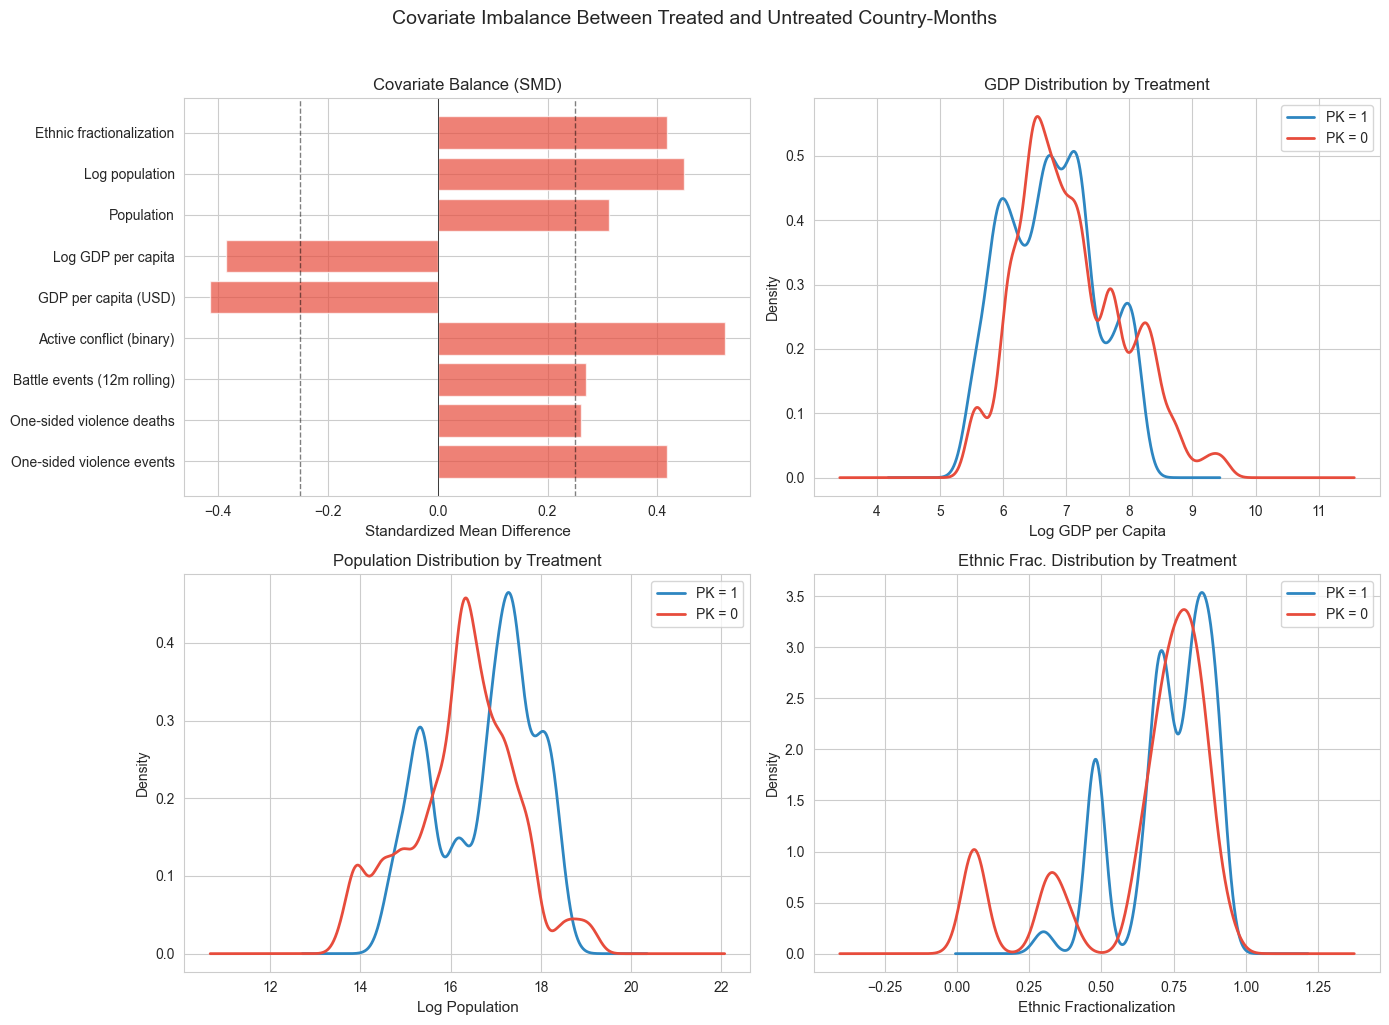

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: SMD bar chart
ax = axes[0, 0]
colors = ['#E74C3C' if abs(s) > 0.25 else '#2ECC71' for s in balance_df['SMD']]
ax.barh(balance_df['Variable'], balance_df['SMD'], color=colors, alpha=0.7)
ax.axvline(x=0.25, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=-0.25, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Standardized Mean Difference', fontsize=11)
ax.set_title('Covariate Balance (SMD)', fontsize=12)

# Top right: GDP density by treatment
ax = axes[0, 1]
panel[panel['pk_present'] == 1]['ln_gdp_pc'].plot.kde(ax=ax, label='PK = 1', color='#2E86C1', linewidth=2)
panel[panel['pk_present'] == 0]['ln_gdp_pc'].plot.kde(ax=ax, label='PK = 0', color='#E74C3C', linewidth=2)
ax.set_xlabel('Log GDP per Capita', fontsize=11)
ax.set_title('GDP Distribution by Treatment', fontsize=12)
ax.legend(fontsize=10)

# Bottom left: Population density by treatment
ax = axes[1, 0]
panel[panel['pk_present'] == 1]['ln_population'].plot.kde(ax=ax, label='PK = 1', color='#2E86C1', linewidth=2)
panel[panel['pk_present'] == 0]['ln_population'].plot.kde(ax=ax, label='PK = 0', color='#E74C3C', linewidth=2)
ax.set_xlabel('Log Population', fontsize=11)
ax.set_title('Population Distribution by Treatment', fontsize=12)
ax.legend(fontsize=10)

# Bottom right: Ethnic fractionalization by treatment
ax = axes[1, 1]
panel[panel['pk_present'] == 1]['ethnic_frac'].plot.kde(ax=ax, label='PK = 1', color='#2E86C1', linewidth=2)
panel[panel['pk_present'] == 0]['ethnic_frac'].plot.kde(ax=ax, label='PK = 0', color='#E74C3C', linewidth=2)
ax.set_xlabel('Ethnic Fractionalization', fontsize=11)
ax.set_title('Ethnic Frac. Distribution by Treatment', fontsize=12)
ax.legend(fontsize=10)

plt.suptitle('Covariate Imbalance Between Treated and Untreated Country-Months', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/covariate_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Selection Bias: The Naive Comparison

This is the core motivation for the entire project. A naive comparison of violence levels between country-months with and without peacekeeping shows MORE violence where peacekeepers are present. This is not because peacekeeping causes violence. It is because the UN sends missions to the most violent places. Showing this bias explicitly demonstrates why simple comparisons are misleading and why causal methods are needed.

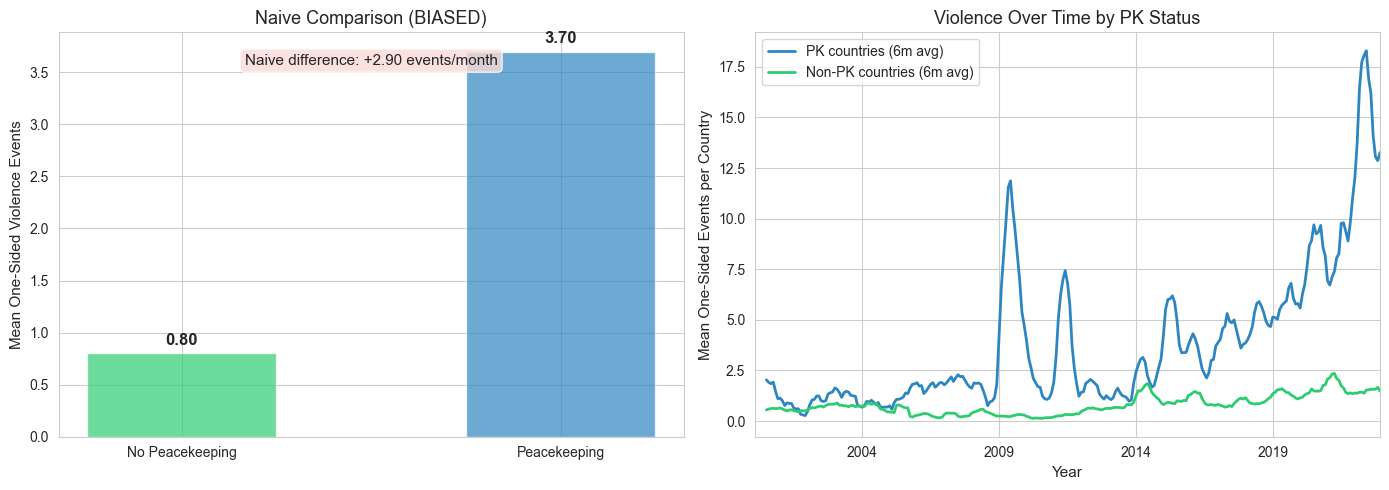

This positive naive difference is SELECTION BIAS.
Countries with PK missions are more violent BEFORE deployment.
DML and Causal Forests in Notebook 03 will correct for this.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of mean violence by treatment
ax = axes[0]
means = panel.groupby('pk_present')['onesided_events'].mean()
bars = ax.bar(['No Peacekeeping', 'Peacekeeping'], means.values, 
              color=['#2ECC71', '#2E86C1'], alpha=0.7, width=0.5)
ax.set_ylabel('Mean One-Sided Violence Events', fontsize=11)
ax.set_title('Naive Comparison (BIASED)', fontsize=13)

for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.text(0.5, 0.92, f'Naive difference: +{means[1] - means[0]:.2f} events/month',
        transform=ax.transAxes, ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.8))

# Right: monthly violence for PK countries vs non-PK countries
ax = axes[1]
pk_monthly = (panel[panel['pk_present'] == 1]
              .groupby('date')['onesided_events'].mean())
no_pk_monthly = (panel[panel['pk_present'] == 0]
                 .groupby('date')['onesided_events'].mean())

pk_monthly.rolling(6).mean().plot(ax=ax, label='PK countries (6m avg)', 
                                   color='#2E86C1', linewidth=2)
no_pk_monthly.rolling(6).mean().plot(ax=ax, label='Non-PK countries (6m avg)', 
                                      color='#2ECC71', linewidth=2)
ax.set_ylabel('Mean One-Sided Events per Country', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_title('Violence Over Time by PK Status', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/selection_bias.png', dpi=150, bbox_inches='tight')
plt.show()

print("This positive naive difference is SELECTION BIAS.")
print("Countries with PK missions are more violent BEFORE deployment.")
print("DML and Causal Forests in Notebook 03 will correct for this.")

## 7. Correlation Structure

A correlation heatmap shows which confounders are most associated with both treatment and outcome. Variables that correlate with both are the strongest confounders and the most important for the causal model to control for.

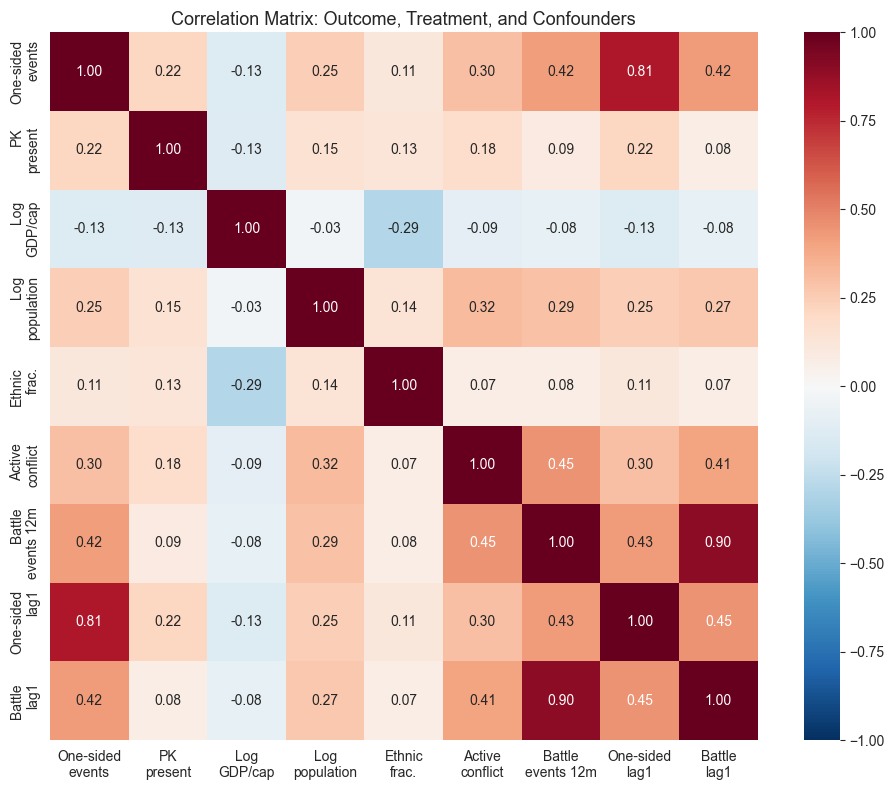

Key correlations with treatment (pk_present):
  onesided_events          : +0.22
  onesided_events_lag1     : +0.22
  active_conflict          : +0.18
  ln_population            : +0.15
  ln_gdp_pc                : -0.13
  ethnic_frac              : +0.13
  battle_events_12m        : +0.09
  battle_events_lag1       : +0.08

Key correlations with outcome (onesided_events):
  onesided_events_lag1     : +0.81
  battle_events_lag1       : +0.42
  battle_events_12m        : +0.42
  active_conflict          : +0.30
  ln_population            : +0.25
  pk_present               : +0.22
  ln_gdp_pc                : -0.13
  ethnic_frac              : +0.11


In [8]:
# Select variables for correlation
corr_vars = ['onesided_events', 'pk_present', 'ln_gdp_pc', 'ln_population',
             'ethnic_frac', 'active_conflict', 'battle_events_12m',
             'onesided_events_lag1', 'battle_events_lag1']

corr_labels = ['One-sided\nevents', 'PK\npresent', 'Log\nGDP/cap', 'Log\npopulation',
               'Ethnic\nfrac.', 'Active\nconflict', 'Battle\nevents 12m',
               'One-sided\nlag1', 'Battle\nlag1']

corr_matrix = panel[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=corr_labels, yticklabels=corr_labels,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation Matrix: Outcome, Treatment, and Confounders', fontsize=13)

plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight key correlations
print("Key correlations with treatment (pk_present):")
pk_corr = corr_matrix['pk_present'].drop('pk_present').sort_values(key=abs, ascending=False)
for var, val in pk_corr.items():
    print(f"  {var:25s}: {val:+.2f}")

print(f"\nKey correlations with outcome (onesided_events):")
ov_corr = corr_matrix['onesided_events'].drop('onesided_events').sort_values(key=abs, ascending=False)
for var, val in ov_corr.items():
    print(f"  {var:25s}: {val:+.2f}")